In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\_nonaromatic_2025_1022_CHS.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
3,"n-Butyl (1,1-dimethylbutyl) sulfide",C10H22S,174,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCSC(C)(C)CCC,CHS
136,"Disulfide, dihexyl",C12H26S2,234,10496-15-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCSSCCCCCC,CHS
259,"Propane, 1,1'-thiobis-",C6H14S,118,111-47-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCSCCC,CHS
382,"Disulfide, ethyl 1-methylethyl",C5H12S2,136,53966-36-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSSC(C)C,CHS
742,"2-Ethylthio-2,3-dimethylbutane",C8H18S,146,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSC(C)(C)C(C)C,CHS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182044,Ethyl n-butyl disulphide,C6H14S2,150,63986-03-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCSSCC,CHS
182121,"Trisulfide, diethyl",C4H10S3,154,3600-24-6,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSSSCC,CHS
182129,"Disulfide, ethyl 2-methylpropyl",C6H14S2,150,40136-66-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSSCC(C)C,CHS
182159,"Carbonotrithioic acid, diethyl ester",C5H10S3,166,2314-49-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCSC(=S)SCC,CHS


In [6]:
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.

X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds

<DiskDataset X.shape: (np.int64(1022), np.int64(600)), y.shape: (np.int64(1022),), w.shape: (np.int64(1022),), task_names: [0]>

In [7]:
# Make a dictionary of all 'SELFIES' parts in the dataset
dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/C]': 3,
 '[/S]': 4,
 '[=Branch1]': 5,
 '[=Branch2]': 6,
 '[=CH0]': 7,
 '[=C]': 8,
 '[=N]': 9,
 '[=SH0]': 10,
 '[=S]': 11,
 '[Branch1]': 12,
 '[Branch2]': 13,
 '[C@@H1]': 14,
 '[C@@]': 15,
 '[C@H1]': 16,
 '[C@]': 17,
 '[CH0]': 18,
 '[CH1]': 19,
 '[CH2]': 20,
 '[C]': 21,
 '[N]': 22,
 '[O]': 23,
 '[P]': 24,
 '[Ring1]': 25,
 '[Ring2]': 26,
 '[S]': 27,
 '[\\-Ring1]': 28,
 '[\\C]': 29,
 '[\\S]': 30,
 '[nop]': 31}

In [8]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

----------------------------

In [18]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.8,
    frac_valid=0,
    frac_test=0.2,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 812
📦 Validation set size: 0
📦 Test set size: 210


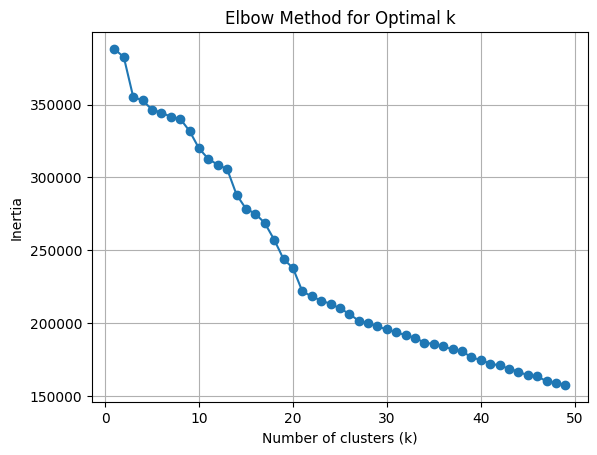

🔍 Elbow point detected at k = 5


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 50)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [ ]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=5,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5)

✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

In [25]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(5):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (86, 600)
Cluster 1 shape: (277, 600)
Cluster 2 shape: (241, 600)
Cluster 3 shape: (67, 600)
Cluster 4 shape: (141, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\spli

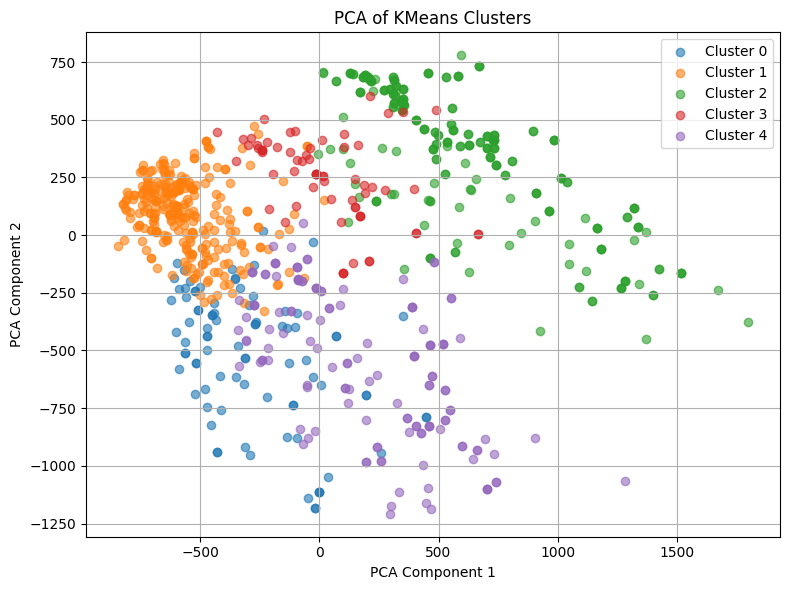

In [27]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5 )
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [28]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:
import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_

Cluster 0: size = 22, shape = (22, 600)
Cluster 1: size = 78, shape = (78, 600)
Cluster 2: size = 53, shape = (53, 600)
Cluster 3: size = 18, shape = (18, 600)
Cluster 4: size = 39, shape = (39, 600)


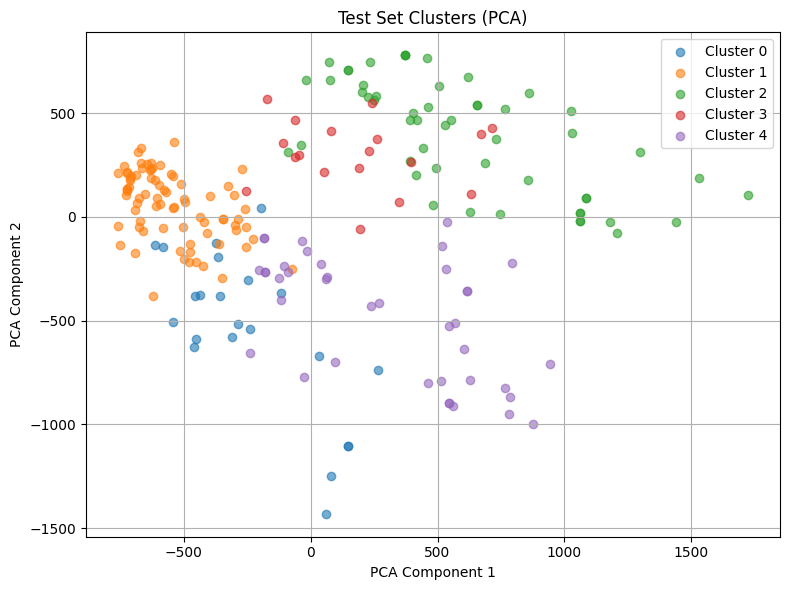

In [30]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(5):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 2.353946
Epoch 2/100 - Loss: 0.279006
Epoch 3/100 - Loss: 0.067018
Epoch 4/100 - Loss: 0.055740
Epoch 5/100 - Loss: 0.053507
Epoch 6/100 - Loss: 0.050008
Epoch 7/100 - Loss: 0.040990
Epoch 8/100 - Loss: 0.034392
Epoch 9/100 - Loss: 0.030039
Epoch 10/100 - Loss: 0.027646
Epoch 11/100 - Loss: 0.025386
Epoch 12/100 - Loss: 0.023404
Epoch 13/100 - Loss: 0.022232
Epoch 14/100 - Loss: 0.021368
Epoch 15/100 - Loss: 0.020469
Epoch 16/100 - Loss: 0.019381
Epoch 17/100 - Loss: 0.018666
Epoch 18/100 - Loss: 0.017587
Epoch 19/100 - Loss: 0.016839
Epoch 20/100 - Loss: 0.016157
Epoch 21/100 - Loss: 0.015382
Epoch 22/100 - Loss: 0.014467
Epoch 23/100 - Loss: 0.013656
Epoch 24/100 - Loss: 0.013178
Epoch 25/100 - Loss: 0.012240
Epoch 26/100 - Loss: 0.011718
Epoch 27/100 - Loss: 0.011081
Epoch 28/100 - Loss: 0.010478
Epoch 29/100 - Loss: 0.009844
Epoch 30/100 - Loss: 0.008955
Epoch 31/100 - Loss: 0.008440
Epoch 32/100 - Loss: 0.008208
Epoch 33/100 - Loss: 0.007755
Epoch 34/100 - Loss

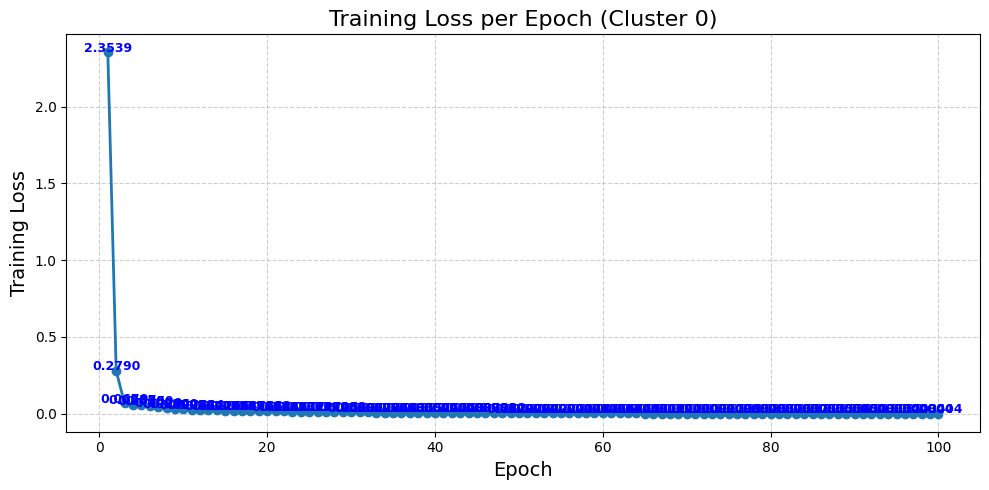

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\models_\model0000


In [31]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [32]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [33]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (22, 2080, 2)
Example prediction: [[1.00000000e+00 5.76235124e-17]
 [1.00000000e+00 8.69551572e-15]
 [1.00000000e+00 7.59711196e-13]
 ...
 [1.00000000e+00 1.24415045e-14]
 [1.00000000e+00 8.05142271e-17]
 [5.17140671e-11 1.00000000e+00]]


In [34]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [35]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [ ]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)

[0] Pred: CC1CC2CCCCC2CS1 | True: CC1CC2CCCCC2CS1 | Tanimoto: 1.000
[1] Pred: C1CCCC=C1 | True: CCSCC#CCSCC | Tanimoto: 0.031
[2] Pred: C1CC2CCC(C1)S2 | True: C1CC2CCC(C1)S2 | Tanimoto: 1.000
[3] Pred: C1CC2CSC(C1)C2 | True: C1CC2CSC(C1)C2 | Tanimoto: 1.000
[4] Pred: CC1(C)C2CCC(C)(C2)C1=S | True: CC1(C)C2CCC(C)(C2)C1=S | Tanimoto: 1.000
[5] Pred: CC(C)CCC[C@@H1](C)[C@H1]1CC[C@H1]2[C@@H1]3CCC4=CC(S)CC[C@]4(C)[C@H1]3CC[C@]12C | True: CC(C)CCC[C@@H1](C)[C@H1]1CC[C@H1]2[C@@H1]3CCC4=CC(S)CC[C@]4(C)[C@H1]3CC[C@]12C | Tanimoto: 1.000
[6] Pred: C1CC2CCC(CC2)S1 | True: C1CC2CCC(CC2)S1 | Tanimoto: 1.000
[7] Pred: C1C2CC3CC1CC(C2)S3 | True: C1C2CC3CC1CC(C2)S3 | Tanimoto: 1.000
[8] Pred: CCSCCCC=CCC | True: CCSCCCC=CCC | Tanimoto: 1.000
[9] Pred: CC12CCC(C1)C(C)(C)C23SCCCS3 | True: CC12CCC(C1)C(C)(C)C23SCCCS3 | Tanimoto: 1.000
[10] Pred: C1C2CCC3SC3C21 | True: C1CCC2SC2CC1 | Tanimoto: 0.415
[11] Pred: C12CCC=C1SCC3=C(CCCC3)S2 | True: CCC1=C(C)CCC1=S | Tanimoto: 0.118
[12] Pred: CC1CC2CSSC[C@@H1]2

Epoch 1/100 - Loss: 0.799150
Epoch 2/100 - Loss: 0.058948
Epoch 3/100 - Loss: 0.041288
Epoch 4/100 - Loss: 0.030382
Epoch 5/100 - Loss: 0.026124
Epoch 6/100 - Loss: 0.024534
Epoch 7/100 - Loss: 0.022968
Epoch 8/100 - Loss: 0.021414
Epoch 9/100 - Loss: 0.020028
Epoch 10/100 - Loss: 0.018703
Epoch 11/100 - Loss: 0.017630
Epoch 12/100 - Loss: 0.016700
Epoch 13/100 - Loss: 0.015720
Epoch 14/100 - Loss: 0.014992
Epoch 15/100 - Loss: 0.013929
Epoch 16/100 - Loss: 0.013383
Epoch 17/100 - Loss: 0.012509
Epoch 18/100 - Loss: 0.011798
Epoch 19/100 - Loss: 0.011169
Epoch 20/100 - Loss: 0.010331
Epoch 21/100 - Loss: 0.009751
Epoch 22/100 - Loss: 0.009115
Epoch 23/100 - Loss: 0.008410
Epoch 24/100 - Loss: 0.007962
Epoch 25/100 - Loss: 0.007330
Epoch 26/100 - Loss: 0.006782
Epoch 27/100 - Loss: 0.006246
Epoch 28/100 - Loss: 0.005843
Epoch 29/100 - Loss: 0.005364
Epoch 30/100 - Loss: 0.004914
Epoch 31/100 - Loss: 0.004638
Epoch 32/100 - Loss: 0.004426
Epoch 33/100 - Loss: 0.004087
Epoch 34/100 - Loss

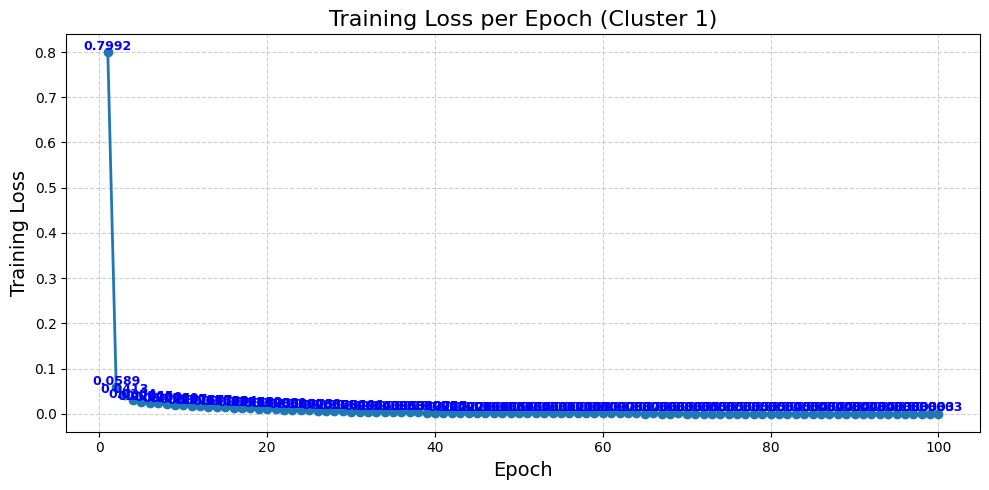

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model1111


In [ ]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)

In [ ]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (78, 2080, 2)
Example prediction: [[1.0000000e+00 3.7552562e-11]
 [1.0000000e+00 9.0470730e-13]
 [1.0000000e+00 1.4398910e-10]
 ...
 [1.0000000e+00 2.2330921e-14]
 [1.0000000e+00 6.1152604e-11]
 [3.5584480e-09 1.0000000e+00]]
[0] Pred: C1CSSC1 | True: C1CSSC1 | Tanimoto: 1.000
[1] Pred: CCSSSCC | True: CCSSSCC | Tanimoto: 1.000
[2] Pred: CCSCCCSCCC | True: C1CCSSC1 | Tanimoto: 0.167
[3] Pred: CCCC=CCSCS=CC | True: SC1CCC1 | Tanimoto: 0.118
[4] Pred: CCC(=S)SCC=CC | True: CCC(=S)SC(C)C=C | Tanimoto: 0.616
[5] Pred: CCCS=C | True: CC1=C(C)SC(S1)=C2SC(=C(C)S2)C | Tanimoto: 0.036
[6] Pred: CCS | True: CSS | Tanimoto: 0.200
[7] Pred: CCC=C | True: C1CC2SC2C1 | Tanimoto: 0.063
[8] Pred: C1CS1 | True: CCSC=C | Tanimoto: 0.474
[9] Pred: CCCCCC | True: CCCSC=C | Tanimoto: 0.125
[10] Pred: CSCC=C | True: CSCSSC | Tanimoto: 0.143
[11] Pred: CSCCCCS | True: CSCCCCS | Tanimoto: 1.000
[12] Pred: CSCCC=CCSCC | True: CSCCCCCCSC | Tanimoto: 0.216
[13] Pred: CCCCCCSC | True: CC(S)C(C

Epoch 1/100 - Loss: 0.857202
Epoch 2/100 - Loss: 0.040316
Epoch 3/100 - Loss: 0.032002
Epoch 4/100 - Loss: 0.022600
Epoch 5/100 - Loss: 0.015580
Epoch 6/100 - Loss: 0.012260
Epoch 7/100 - Loss: 0.010563
Epoch 8/100 - Loss: 0.009578
Epoch 9/100 - Loss: 0.008666
Epoch 10/100 - Loss: 0.007912
Epoch 11/100 - Loss: 0.007222
Epoch 12/100 - Loss: 0.006616
Epoch 13/100 - Loss: 0.006134
Epoch 14/100 - Loss: 0.005536
Epoch 15/100 - Loss: 0.005222
Epoch 16/100 - Loss: 0.004778
Epoch 17/100 - Loss: 0.004608
Epoch 18/100 - Loss: 0.004403
Epoch 19/100 - Loss: 0.003809
Epoch 20/100 - Loss: 0.003439
Epoch 21/100 - Loss: 0.003348
Epoch 22/100 - Loss: 0.003024
Epoch 23/100 - Loss: 0.002862
Epoch 24/100 - Loss: 0.002616
Epoch 25/100 - Loss: 0.002486
Epoch 26/100 - Loss: 0.002256
Epoch 27/100 - Loss: 0.002163
Epoch 28/100 - Loss: 0.002026
Epoch 29/100 - Loss: 0.001869
Epoch 30/100 - Loss: 0.001808
Epoch 31/100 - Loss: 0.001735
Epoch 32/100 - Loss: 0.001580
Epoch 33/100 - Loss: 0.001594
Epoch 34/100 - Loss

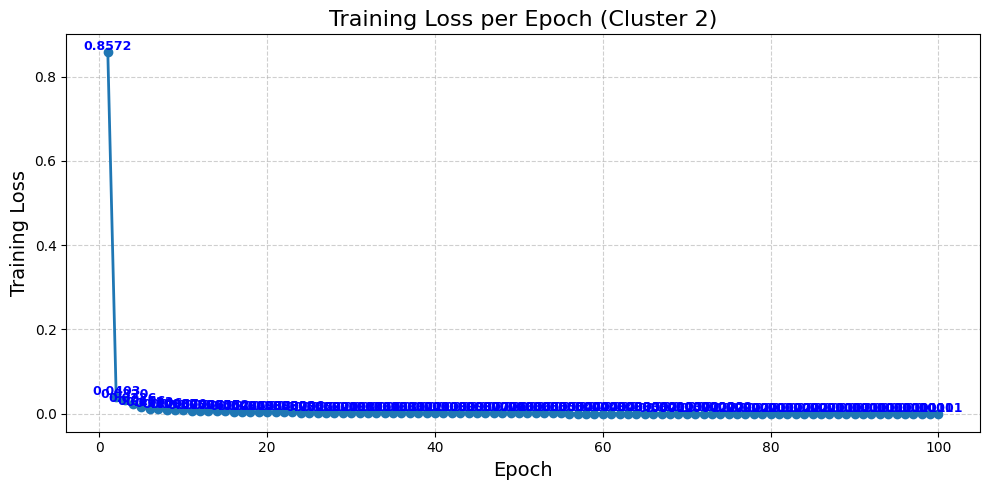

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model2222


In [39]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

# Ensure y is 2D
if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_1
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])
evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (53, 2080, 2)
Example prediction: [[1.0000000e+00 2.3155116e-14]
 [1.0000000e+00 9.9875031e-22]
 [1.0000000e+00 3.7780083e-15]
 ...
 [1.0000000e+00 2.1979943e-13]
 [1.0000000e+00 3.6313037e-17]
 [4.2760989e-15 1.0000000e+00]]
[0] Pred: CCCSCCC | True: CCCSCCC | Tanimoto: 1.000
[1] Pred: CCCCCSSCCC(C)C | True: CCCCCSSCCC(C)C | Tanimoto: 1.000
[2] Pred: CCCCCCCCCCCCCCCCCCSSCCCCCCCCCCCCCCCCCC | True: CCCCCCCCCCCCCCCCCCSSCCCCCCCCCCCCCCCCCC | Tanimoto: 1.000
[3] Pred: CCCSSC(C)C | True: CCCSSC(C)C | Tanimoto: 1.000
[4] Pred: CCCCCSSCCC | True: CCCCCSSCCC | Tanimoto: 1.000
[5] Pred: CCCSSC(C)CCC | True: CCC(C)SSC(C)C | Tanimoto: 0.727
[6] Pred: CSC(C)(C)C(C)C | True: CSC(C)(C)C(C)C | Tanimoto: 1.000
[7] Pred: CCCCCCCCCCCCSCC | True: CCCCCCCCCCCCSCC | Tanimoto: 1.000
[8] Pred: CCCCCCCCCS | True: CCCCCCCCCS | Tanimoto: 1.000
[9] Pred: CCCCCCCCCCCCS | True: CCCCCCCCCCCCS | Tanimoto: 1.000
[10] Pred: CCCCCCCCCSC | True: CCCCCCCCCSC | Tanimoto: 1.000
[11] Pred: CCCCCCCCCCCCCCC

Epoch 1/100 - Loss: 1.498007
Epoch 2/100 - Loss: 0.200364
Epoch 3/100 - Loss: 0.038176
Epoch 4/100 - Loss: 0.027877
Epoch 5/100 - Loss: 0.029627
Epoch 6/100 - Loss: 0.027617
Epoch 7/100 - Loss: 0.023211
Epoch 8/100 - Loss: 0.021593
Epoch 9/100 - Loss: 0.018741
Epoch 10/100 - Loss: 0.016855
Epoch 11/100 - Loss: 0.014853
Epoch 12/100 - Loss: 0.013411
Epoch 13/100 - Loss: 0.012440
Epoch 14/100 - Loss: 0.011873
Epoch 15/100 - Loss: 0.010595
Epoch 16/100 - Loss: 0.009624
Epoch 17/100 - Loss: 0.009084
Epoch 18/100 - Loss: 0.008503
Epoch 19/100 - Loss: 0.008031
Epoch 20/100 - Loss: 0.007608
Epoch 21/100 - Loss: 0.007216
Epoch 22/100 - Loss: 0.006744
Epoch 23/100 - Loss: 0.006415
Epoch 24/100 - Loss: 0.006202
Epoch 25/100 - Loss: 0.005827
Epoch 26/100 - Loss: 0.005402
Epoch 27/100 - Loss: 0.005231
Epoch 28/100 - Loss: 0.005027
Epoch 29/100 - Loss: 0.004857
Epoch 30/100 - Loss: 0.004840
Epoch 31/100 - Loss: 0.004524
Epoch 32/100 - Loss: 0.004178
Epoch 33/100 - Loss: 0.004211
Epoch 34/100 - Loss

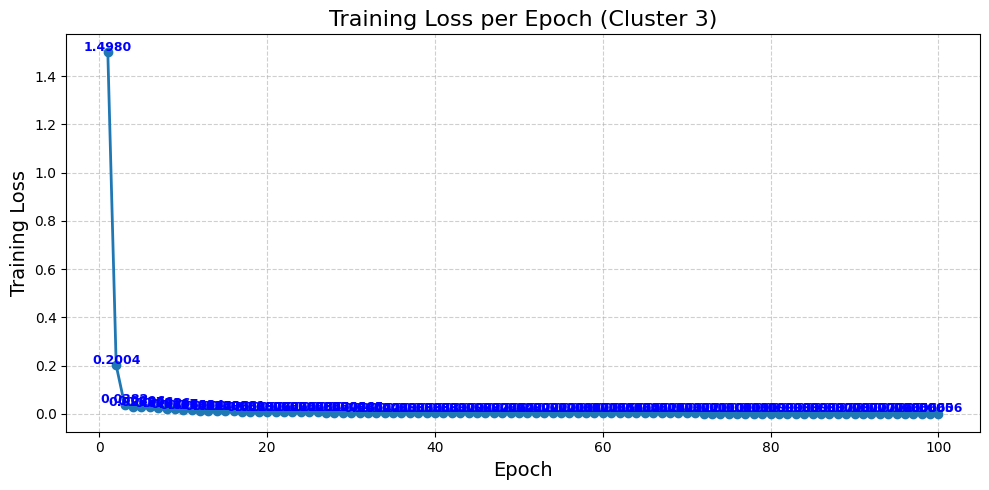

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model3


In [41]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

# Ensure y is 2D
if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model3"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_1
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])
evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (18, 2080, 2)
Example prediction: [[1.0000000e+00 1.8027326e-12]
 [1.0000000e+00 7.0551735e-13]
 [1.0000000e+00 1.7598046e-11]
 ...
 [1.0000000e+00 1.1748314e-16]
 [1.0000000e+00 3.4921642e-13]
 [9.4433101e-14 1.0000000e+00]]
[0] Pred: CC1SC2=C(SC1C)SC(S2)=C3SC4=C(SC(C)C(C)S4)S3 | True: CC1SC2=C(SC1C)SC(S2)=C3SC4=C(SC(C)C(C)S4)S3 | Tanimoto: 1.000
[1] Pred: CCC(C)CS | True: CCC(C)CS | Tanimoto: 1.000
[2] Pred: CCCCSSCC | True: CCCCSSCC | Tanimoto: 1.000
[3] Pred: CCCCCCS(C)C | True: CCC(C)SC(C)CC | Tanimoto: 0.261
[4] Pred: CC(C)(C)SCCCC=C | True: CCSCC=CCC(C)(C)C | Tanimoto: 0.248
[5] Pred: CCCCCSCC(C)C | True: CCC(C)SCC(C)C | Tanimoto: 0.531
[6] Pred: CCCC(S)(CC)CC | True: CC(C)(C)CC(C)(C)S | Tanimoto: 0.466
[7] Pred: CCCCCCCCCCC | True: CCCCC(C)(C)S | Tanimoto: 0.208
[8] Pred: CCCCCC(C)C | True: CCCCC(CC)CS | Tanimoto: 0.385
[9] Pred: CC(C)CSC(C)(C)C | True: CCCCCCSSC(C)(C)C | Tanimoto: 0.170
[10] Pred: CCCC(S)(CC)CC | True: CCCCCC(C)(C)S | Tanimoto: 0.514
[11] P

Epoch 1/100 - Loss: 1.359975
Epoch 2/100 - Loss: 0.036818
Epoch 3/100 - Loss: 0.030258
Epoch 4/100 - Loss: 0.028717
Epoch 5/100 - Loss: 0.023004
Epoch 6/100 - Loss: 0.019814
Epoch 7/100 - Loss: 0.015193
Epoch 8/100 - Loss: 0.012948
Epoch 9/100 - Loss: 0.011082
Epoch 10/100 - Loss: 0.009501
Epoch 11/100 - Loss: 0.008369
Epoch 12/100 - Loss: 0.007683
Epoch 13/100 - Loss: 0.007258
Epoch 14/100 - Loss: 0.006693
Epoch 15/100 - Loss: 0.006176
Epoch 16/100 - Loss: 0.005825
Epoch 17/100 - Loss: 0.005316
Epoch 18/100 - Loss: 0.004788
Epoch 19/100 - Loss: 0.004554
Epoch 20/100 - Loss: 0.004150
Epoch 21/100 - Loss: 0.003901
Epoch 22/100 - Loss: 0.003661
Epoch 23/100 - Loss: 0.003293
Epoch 24/100 - Loss: 0.002974
Epoch 25/100 - Loss: 0.002738
Epoch 26/100 - Loss: 0.002579
Epoch 27/100 - Loss: 0.002365
Epoch 28/100 - Loss: 0.002311
Epoch 29/100 - Loss: 0.001989
Epoch 30/100 - Loss: 0.001889
Epoch 31/100 - Loss: 0.001732
Epoch 32/100 - Loss: 0.001568
Epoch 33/100 - Loss: 0.001502
Epoch 34/100 - Loss

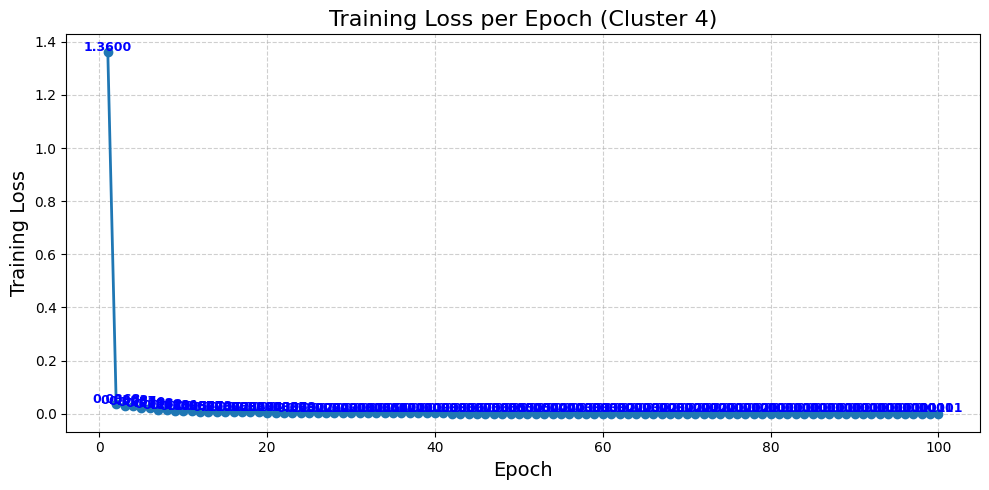

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model4


In [43]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

# Ensure y is 2D
if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with seed 123\models_\model4"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_1022_CHS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

if len(y_test_cluster4.shape) == 1:
    y_test_cluster4= y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_1
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])
evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (39, 2080, 2)
Example prediction: [[1.0000000e+00 8.0199798e-15]
 [1.0000000e+00 3.2013772e-09]
 [1.0000000e+00 7.9479101e-10]
 ...
 [1.0000000e+00 1.2197120e-10]
 [1.0000000e+00 6.1848908e-11]
 [1.1994179e-09 1.0000000e+00]]
[0] Pred: CCCCSC1CCCC1 | True: CCCCSC1CCCC1 | Tanimoto: 1.000
[1] Pred: CSC(C)C=CC | True: CSC(C)C=CC | Tanimoto: 1.000
[2] Pred: CSCC(C)=CC | True: CSCC(C)=CC | Tanimoto: 1.000
[3] Pred: CCCCCCSC1CCCC1 | True: CCCCCCSC1CCCC1 | Tanimoto: 1.000
[4] Pred: CC1CS1 | True: CC1CS1 | Tanimoto: 1.000
[5] Pred: CC(C)(C)SCC=C | True: CC(C)(C)SCC=C | Tanimoto: 1.000
[6] Pred: CSSSCC=C | True: CSSSCC=C | Tanimoto: 1.000
[7] Pred: SCCCCCCCCCS | True: SCCCCCCCCCS | Tanimoto: 1.000
[8] Pred: C1CCC(CC1)SC2CCCCC2 | True: C1CCCSSCC1 | Tanimoto: 0.188
[9] Pred: CCCCC[C@@H1]1CCS[C@@H1](C)C1 | True: CCCCC[C@H1]1CCS[C@@H1](C)C1 | Tanimoto: 1.000
[10] Pred: CCCCCCCCCCCCCCC | True: CCCCCCCCC1CCSS1 | Tanimoto: 0.132
[11] Pred: C[C@@H1]1CCC[C@H1]1S | True: C[C@H1]1CCC[C